In [2]:
# 如果需要，可取消注释并改成你的路径
import sys
# sys.path.append(r'.')

from importlib import reload
import os
import low_cut_utils_modified as ref 
reload(ref)
from low_cut_utils_modified import *
import numpy as np
from scipy.signal import peak_prominences
from lgdo import lh5
import numpy as np
import awkward as ak
from lgdo import lh5


In [3]:
filepath = "/mnt/atlas01/users/vogl/scarf/sp01/data/hit_vcs"
files = os.listdir(filepath)
files.sort()
files

pnum_cal = "05"
run_cal = "057"

# bg run 6 days
pnum_phy_bg = "00"
run_phy_bg = "038"
# signal run 13 days
pnum_phy_signal = "05"
run_phy_signal = "059"

runs = [
 's100ns_mw3', 's100ns_mw5', 's100ns_mw7',
   's200ns_mw3', 's200ns_mw5', 's200ns_mw7',
    # 's60ns_mw3', 's60ns_mw5', 's60ns_mw7',
    # 's60ns_mw1', 's100ns_mw1', 's200ns_mw1',
]



def build_run_db(runs, filepath):
    db = {}
    missing = []

    for run in runs:
        m = re.match(r"s(\d+)ns_mw(\d+)", run)
        if not m:
            missing.append(f"{run}: invalid run name format")
            continue

        run_path = os.path.join(filepath, run)

        phy_bg_path = os.path.join(run_path, "phy", f"p{pnum_phy_bg}", f"r{run_phy_bg}")
        phy_signal_path = os.path.join(run_path, "phy", f"p{pnum_phy_signal}", f"r{run_phy_signal}")
        cal_path = os.path.join(run_path, "cal", f"p{pnum_cal}", f"r{run_cal}")
        missing_this_run = []
        if not os.path.exists(run_path):
            missing_this_run.append(f"run folder missing: {run_path}")
        if not os.path.exists(phy_bg_path):
            missing_this_run.append(f"phy_bg path missing: {phy_bg_path}")
        if not os.path.exists(phy_signal_path):
            missing_this_run.append(f"phy_signal path missing: {phy_signal_path}")
        if not os.path.exists(cal_path):
            missing_this_run.append(f"cal path missing: {cal_path}")
        if missing_this_run:
            missing.append(f"{run}\n  " + "\n  ".join(missing_this_run))
            continue

        phy_bg_files = sorted(os.listdir(phy_bg_path))
        phy_signal_files = sorted(os.listdir(phy_signal_path))
        cal_files = sorted(os.listdir(cal_path))

        db[run] = {
            "run": run,
            "time_ns": int(m.group(1)),
            "mw": int(m.group(2)),
            "interval": f"{m.group(1)}ns",
            "mw_label": f"mw{m.group(2)}",
            "phy_bg_path": phy_bg_path,
            "phy_signal_path": phy_signal_path,
            "cal_path": cal_path,
            "phy_bg_files": phy_bg_files,
            "phy_signal_files": phy_signal_files,
            "cal_files": cal_files,
            "phy_bg_pathlist": [os.path.join(phy_bg_path, f) for f in phy_bg_files],
            "phy_signal_pathlist": [os.path.join(phy_signal_path, f) for f in phy_signal_files],
            "cal_pathlist": [os.path.join(cal_path, f) for f in cal_files],
        }

    if missing:
        raise FileNotFoundError(
            "[ERROR] Some runs or paths are missing:\n\n" + "\n\n".join(missing)
        )
    return db
run_db = build_run_db(runs, filepath)


In [4]:
all_db = load_pkl("all_lowcut_event_fix_db_r57r59.pkl")

loaded from all_lowcut_event_fix_db_r57r59.pkl


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erfc


def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def left_exgauss_tail(x, A, mu_tail, sigma_tail, tau):
    """
    Low-A/E left tail component.
    """
    lam = 1.0 / tau

    return (
        A * lam / 2.0
        * np.exp(
            lam * (x - mu_tail)
            + 0.5 * (lam * sigma_tail) ** 2
        )
        * erfc(
            (x - mu_tail + lam * sigma_tail**2)
            / (np.sqrt(2) * sigma_tail)
        )
    )


def aoe_peak_plus_slow_tail(
    x,
    A_peak,
    mu_peak,
    sigma_peak,
    A_tail,
    mu_tail,
    sigma_tail,
    tau,
    C,
):
    peak = gaussian(x, A_peak, mu_peak, sigma_peak)
    tail = left_exgauss_tail(x, A_tail, mu_tail, sigma_tail, tau)
    bg = C * np.ones_like(x)

    return peak + tail + bg

In [6]:
from aoe_tail_fit_utils import *
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.special import erfc

In [7]:
def get_hist_arrays_from_hist_db(
    hist_db,
    hist_key="ROI_Signal",
    counts_key="counts",
):
    hist_item = hist_db[hist_key]

    centers = np.asarray(hist_item["centers"], dtype=float)
    counts = np.asarray(hist_item[counts_key], dtype=float)

    finite = np.isfinite(centers) & np.isfinite(counts)

    return centers[finite], counts[finite]

In [15]:
def fit_aoe_tail_from_hist_db(
    hist_db,
    hist_key="ROI_Signal",
    counts_key="counts",
    fit_range=(0.75, 1.08),
    p0=None,
    bounds=None,
    remove_zero_bins=True,
):
    """
    Fit one histogram from hist_db.

    Returns a dict containing fit parameters, errors, arrays, and components.
    """
    centers, counts = get_hist_arrays_from_hist_db(
        hist_db,
        hist_key=hist_key,
        counts_key=counts_key,
    )

    mask = (
        np.isfinite(centers)
        & np.isfinite(counts)
        & (centers >= fit_range[0])
        & (centers <= fit_range[1])
    )

    x_fit = centers[mask]
    y_fit = counts[mask]

    if remove_zero_bins:
        nonzero = y_fit > 0
        x_fit = x_fit[nonzero]
        y_fit = y_fit[nonzero]

    if len(x_fit) < 8:
        raise ValueError("Not enough valid bins in fit range.")

    yerr = np.sqrt(np.maximum(y_fit, 1.0))

    if p0 is None:
        ymax = np.max(y_fit)
        ymin = np.min(y_fit)

        p0 = [
            ymax,              # A_peak
            1.000,             # mu_peak
            0.012,             # sigma_peak
            0.02 * ymax,       # A_tail
            0.970,             # mu_tail
            0.020,             # sigma_tail
            0.050,             # tau
            max(ymin, 0.0),    # C
        ]

    if bounds is None:
        bounds = (
            [
                0.0,   0.95, 0.001,
                0.0,   0.75, 0.001,
                0.001, 0.0,
            ],
            [
                np.inf, 1.05, 0.100,
                np.inf, 1.03, 0.100,
                0.300, np.inf,
            ],
        )

    popt, pcov = curve_fit(
        aoe_peak_plus_slow_tail,
        x_fit,
        y_fit,
        p0=p0,
        sigma=yerr,
        absolute_sigma=True,
        bounds=bounds,
        maxfev=100000,
    )

    if pcov is None or not np.all(np.isfinite(pcov)):
        perr = np.full(len(popt), np.nan)
    else:
        perr = np.sqrt(np.diag(pcov))

    names = [
        "A_peak",
        "mu_peak",
        "sigma_peak",
        "A_tail",
        "mu_tail",
        "sigma_tail",
        "tau",
        "C",
    ]

    result = {
        "success": True,
        "popt": popt,
        "pcov": pcov,
        "perr": perr,
        "param_names": names,

        "x_fit": x_fit,
        "y_fit": y_fit,
        "yerr": yerr,

        "centers_all": centers,
        "counts_all": counts,

        "fit_range": fit_range,
        "hist_key": hist_key,
        "counts_key": counts_key,
    }

    for name, val, err in zip(names, popt, perr):
        result[name] = float(val)
        result[name + "_err"] = float(err)

    A_peak, mu_peak, sigma_peak, A_tail, mu_tail, sigma_tail, tau, C = popt

    result["tail_to_peak_amp"] = float(A_tail / A_peak) if A_peak > 0 else np.nan
    result["mu_separation"] = float(mu_peak - mu_tail)
    result["tail_width_over_peak_width"] = (
        float(sigma_tail / sigma_peak) if sigma_peak > 0 else np.nan
    )

    return result

In [9]:
def plot_aoe_tail_fit(
    fit_result,
    threshold=1.0,
    title=None,
    ylim=(1, 1e4),
    log_y=True,
    show_data=True,
    show_components=True,
    shade_tail_above_threshold=True,
):
    """
    Plot fit result from fit_aoe_tail_from_hist_db.
    """
    popt = fit_result["popt"]
    fit_range = fit_result["fit_range"]

    A_peak, mu_peak, sigma_peak, A_tail, mu_tail, sigma_tail, tau, C = popt

    x_plot = np.linspace(fit_range[0], fit_range[1], 1200)

    y_total = aoe_peak_plus_slow_tail(x_plot, *popt)
    y_peak = gaussian(x_plot, A_peak, mu_peak, sigma_peak)
    y_tail = left_exgauss_tail(x_plot, A_tail, mu_tail, sigma_tail, tau)
    y_bg = C * np.ones_like(x_plot)

    fig, ax = plt.subplots(figsize=(8, 5))

    if show_data:
        ax.errorbar(
            fit_result["x_fit"],
            fit_result["y_fit"],
            yerr=fit_result["yerr"],
            fmt=".",
            markersize=3,
            alpha=0.5,
            label=f"{fit_result['hist_key']} histogram",
        )

    ax.plot(x_plot, y_total, linewidth=2, label="total fit")

    if show_components:
        ax.plot(x_plot, y_peak, "--", label="normal A/E peak")
        ax.plot(x_plot, y_tail, "--", label="slow low-A/E tail")
        ax.plot(x_plot, y_bg, ":", label="constant background")

    if shade_tail_above_threshold:
        mask_thr = x_plot > threshold
        y_floor = np.full_like(x_plot[mask_thr], 1e-300)

        ax.fill_between(
            x_plot[mask_thr],
            y_floor,
            y_tail[mask_thr],
            alpha=0.3,
            label=f"tail contribution A/E > {threshold:.2f}",
        )

    ax.axvline(
        mu_peak,
        linestyle="--",
        alpha=0.5,
        label=f"mu_peak = {mu_peak:.4f}",
    )

    ax.axvline(
        mu_tail,
        linestyle="--",
        alpha=0.5,
        label=f"mu_tail = {mu_tail:.4f}",
    )

    ax.axvline(
        threshold,
        linestyle=":",
        alpha=0.8,
        label=f"threshold = {threshold:.2f}",
    )

    ax.set_xlim(fit_range)

    if ylim is not None:
        ax.set_ylim(*ylim)

    if log_y:
        ax.set_yscale("log")

    ax.set_xlabel("A/E")
    ax.set_ylabel("Counts")

    if title is None:
        title = "ROI Signal A/E fit: peak + slow low-A/E tail"

    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

    return fig, ax

In [33]:
def estimate_slow_tail_total_from_fit(fit_result):
    """
    Estimate fitted slow-tail counts.

    Model:
        y_total = y_peak + y_tail + y_bg

    n_slow_tail_total:
        sum of fitted slow-tail component over histogram bin centers
        where y_tail > 0.

    This is not data - bg.
    It is the fitted slow-tail component itself.

    Also returns:
        slow_tail_fraction_of_model = tail / (peak + tail + bg)
        slow_tail_fraction_bg_sub   = tail / (peak + tail)
    """
    centers = np.asarray(fit_result["centers_all"], dtype=float)

    A_peak = fit_result["A_peak"]
    mu_peak = fit_result["mu_peak"]
    sigma_peak = fit_result["sigma_peak"]

    A_tail = fit_result["A_tail"]
    mu_tail = fit_result["mu_tail"]
    sigma_tail = fit_result["sigma_tail"]
    tau = fit_result["tau"]

    C = fit_result["C"]

    y_peak = gaussian(
        centers,
        A_peak,
        mu_peak,
        sigma_peak,
    )

    y_tail = left_exgauss_tail(
        centers,
        A_tail,
        mu_tail,
        sigma_tail,
        tau,
    )

    y_bg = C * np.ones_like(centers)

    y_total = y_peak + y_tail + y_bg

    finite = (
        np.isfinite(centers)
        & np.isfinite(y_peak)
        & np.isfinite(y_tail)
        & np.isfinite(y_bg)
        & np.isfinite(y_total)
    )

    positive_tail = finite & (y_tail > 0)

    n_slow_tail_total = np.sum(y_tail[positive_tail])
    n_peak_total = np.sum(y_peak[finite])
    n_bg_total = np.sum(y_bg[finite])
    n_model_total = np.sum(y_total[finite])

    n_model_bg_sub_total = n_peak_total + n_slow_tail_total

    # Poisson-like count errors
    n_slow_tail_total_err = (
        np.sqrt(n_slow_tail_total)
        if np.isfinite(n_slow_tail_total) and n_slow_tail_total >= 0
        else np.nan
    )

    n_peak_total_err = (
        np.sqrt(n_peak_total)
        if np.isfinite(n_peak_total) and n_peak_total >= 0
        else np.nan
    )

    n_bg_total_err = (
        np.sqrt(n_bg_total)
        if np.isfinite(n_bg_total) and n_bg_total >= 0
        else np.nan
    )

    n_model_total_err = (
        np.sqrt(n_model_total)
        if np.isfinite(n_model_total) and n_model_total >= 0
        else np.nan
    )

    n_model_bg_sub_total_err = (
        np.sqrt(n_model_bg_sub_total)
        if np.isfinite(n_model_bg_sub_total) and n_model_bg_sub_total >= 0
        else np.nan
    )

    # tail fraction with background in denominator
    if n_model_total > 0:
        slow_tail_fraction_of_model = n_slow_tail_total / n_model_total
        slow_tail_fraction_of_model_err = np.sqrt(
            slow_tail_fraction_of_model
            * (1.0 - slow_tail_fraction_of_model)
            / n_model_total
        )
    else:
        slow_tail_fraction_of_model = np.nan
        slow_tail_fraction_of_model_err = np.nan

    # tail fraction with background removed from denominator
    if n_model_bg_sub_total > 0:
        slow_tail_fraction_bg_sub = n_slow_tail_total / n_model_bg_sub_total
        slow_tail_fraction_bg_sub_err = np.sqrt(
            slow_tail_fraction_bg_sub
            * (1.0 - slow_tail_fraction_bg_sub)
            / n_model_bg_sub_total
        )
    else:
        slow_tail_fraction_bg_sub = np.nan
        slow_tail_fraction_bg_sub_err = np.nan

    # tail / peak ratio
    if n_peak_total > 0 and n_slow_tail_total > 0:
        slow_tail_to_peak = n_slow_tail_total / n_peak_total

        slow_tail_to_peak_err = slow_tail_to_peak * np.sqrt(
            (n_slow_tail_total_err / n_slow_tail_total) ** 2
            + (n_peak_total_err / n_peak_total) ** 2
        )
    else:
        slow_tail_to_peak = np.nan
        slow_tail_to_peak_err = np.nan

    return {
        "n_slow_tail_total": float(n_slow_tail_total),
        "n_slow_tail_total_err": float(n_slow_tail_total_err),

        "n_peak_total": float(n_peak_total),
        "n_peak_total_err": float(n_peak_total_err),

        "n_bg_total": float(n_bg_total),
        "n_bg_total_err": float(n_bg_total_err),

        "n_model_total": float(n_model_total),
        "n_model_total_err": float(n_model_total_err),

        "n_model_bg_sub_total": float(n_model_bg_sub_total),
        "n_model_bg_sub_total_err": float(n_model_bg_sub_total_err),

        "slow_tail_fraction_of_model": float(slow_tail_fraction_of_model),
        "slow_tail_fraction_of_model_err": float(slow_tail_fraction_of_model_err),

        "slow_tail_fraction_bg_sub": float(slow_tail_fraction_bg_sub),
        "slow_tail_fraction_bg_sub_err": float(slow_tail_fraction_bg_sub_err),

        "slow_tail_to_peak": float(slow_tail_to_peak),
        "slow_tail_to_peak_err": float(slow_tail_to_peak_err),
    }

In [34]:
def parse_window_mw_from_run(run):
    """
    Parse run name like 's100ns_mw3'.
    """
    m = re.search(r"s(?P<window_ns>\d+)ns_mw(?P<mw>\d+)", str(run))

    if m is None:
        return np.nan, np.nan

    return float(m.group("window_ns")), float(m.group("mw"))


def run_tail_fits_over_runs(
    runs,
    all_db,
    channel,
    bins=250,
    value_range=(0.75, 1.25),
    hist_key="ROI_Signal",
    counts_key="counts",
    fit_range=(0.75, 1.04),
    threshold=1.0,
    plot=True,
    ylim=(1, 1e4),
):
    rows = []
    tail_fit_db = {}

    for run in runs:
        print(f"\n=== {run} | {channel} ===")

        row = {
            "run": run,
            "channel": channel,
        }

        window_ns, mw = parse_window_mw_from_run(run)
        row["window_ns"] = window_ns
        row["mw"] = mw

        try:
            event_db = all_db[run][channel]["event_db"]

            hist_db = make_hist_db_from_event_db(
                event_db,
                bins=bins,
                value_range=value_range,
            )

            fit_result = fit_aoe_tail_from_hist_db(
                hist_db,
                hist_key=hist_key,
                counts_key=counts_key,
                fit_range=fit_range,
            )

            tail_stats = estimate_slow_tail_total_from_fit(fit_result)

            if plot:
                plot_aoe_tail_fit(
                    fit_result,
                    threshold=threshold,
                    title=f"{run} | {channel} | {hist_key} A/E tail fit",
                    ylim=ylim,
                    log_y=True,
                )

            # fit parameters
            for name in fit_result["param_names"]:
                row[name] = fit_result[name]
                row[name + "_err"] = fit_result[name + "_err"]

            # derived fit quantities
            row["tail_to_peak_amp"] = fit_result["tail_to_peak_amp"]
            row["mu_separation"] = fit_result["mu_separation"]
            row["tail_width_over_peak_width"] = fit_result["tail_width_over_peak_width"]

            # fitted component counts
            row["n_slow_tail_total"] = tail_stats["n_slow_tail_total"]
            row["n_slow_tail_total_err"] = tail_stats["n_slow_tail_total_err"]

            row["n_peak_total"] = tail_stats["n_peak_total"]
            row["n_peak_total_err"] = tail_stats["n_peak_total_err"]

            row["n_bg_total"] = tail_stats["n_bg_total"]
            row["n_bg_total_err"] = tail_stats["n_bg_total_err"]

            row["n_model_total"] = tail_stats["n_model_total"]
            row["n_model_total_err"] = tail_stats["n_model_total_err"]

            row["n_model_bg_sub_total"] = tail_stats["n_model_bg_sub_total"]
            row["n_model_bg_sub_total_err"] = tail_stats["n_model_bg_sub_total_err"]

            # fractions
            row["slow_tail_fraction_of_model"] = tail_stats["slow_tail_fraction_of_model"]
            row["slow_tail_fraction_of_model_err"] = tail_stats["slow_tail_fraction_of_model_err"]

            row["slow_tail_fraction_bg_sub"] = tail_stats["slow_tail_fraction_bg_sub"]
            row["slow_tail_fraction_bg_sub_err"] = tail_stats["slow_tail_fraction_bg_sub_err"]

            row["slow_tail_to_peak"] = tail_stats["slow_tail_to_peak"]
            row["slow_tail_to_peak_err"] = tail_stats["slow_tail_to_peak_err"]

            # FOMs
            # lower is better, denominator includes constant bg
            row["fom_slow_tail_fraction"] = tail_stats["slow_tail_fraction_of_model"]
            row["fom_slow_tail_fraction_err"] = tail_stats["slow_tail_fraction_of_model_err"]

            # lower is better, denominator excludes constant bg
            row["fom_slow_tail_fraction_bg_sub"] = tail_stats["slow_tail_fraction_bg_sub"]
            row["fom_slow_tail_fraction_bg_sub_err"] = tail_stats["slow_tail_fraction_bg_sub_err"]

            row["fit_success"] = True
            row["error"] = ""

            print("mu_peak =", row["mu_peak"], "+/-", row["mu_peak_err"])
            print("mu_tail =", row["mu_tail"], "+/-", row["mu_tail_err"])
            print("tau =", row["tau"], "+/-", row["tau_err"])

            print(
                "n_slow_tail_total =",
                row["n_slow_tail_total"],
                "+/-",
                row["n_slow_tail_total_err"],
            )

            print(
                "fom_slow_tail_fraction =",
                row["fom_slow_tail_fraction"],
                "+/-",
                row["fom_slow_tail_fraction_err"],
            )

            print(
                "fom_slow_tail_fraction_bg_sub =",
                row["fom_slow_tail_fraction_bg_sub"],
                "+/-",
                row["fom_slow_tail_fraction_bg_sub_err"],
            )

        except Exception as e:
            print(f"[WARN] fit failed for {run} | {channel}: {e}")

            fit_result = None
            tail_stats = None

            for name in [
                "A_peak",
                "mu_peak",
                "sigma_peak",
                "A_tail",
                "mu_tail",
                "sigma_tail",
                "tau",
                "C",
            ]:
                row[name] = np.nan
                row[name + "_err"] = np.nan

            for name in [
                "tail_to_peak_amp",
                "mu_separation",
                "tail_width_over_peak_width",

                "n_slow_tail_total",
                "n_slow_tail_total_err",

                "n_peak_total",
                "n_peak_total_err",

                "n_bg_total",
                "n_bg_total_err",

                "n_model_total",
                "n_model_total_err",

                "n_model_bg_sub_total",
                "n_model_bg_sub_total_err",

                "slow_tail_fraction_of_model",
                "slow_tail_fraction_of_model_err",

                "slow_tail_fraction_bg_sub",
                "slow_tail_fraction_bg_sub_err",

                "slow_tail_to_peak",
                "slow_tail_to_peak_err",

                "fom_slow_tail_fraction",
                "fom_slow_tail_fraction_err",

                "fom_slow_tail_fraction_bg_sub",
                "fom_slow_tail_fraction_bg_sub_err",
            ]:
                row[name] = np.nan

            row["fit_success"] = False
            row["error"] = str(e)

        rows.append(row)

        if run not in tail_fit_db:
            tail_fit_db[run] = {}

        tail_fit_db[run][channel] = {
            "summary": row,
            "fit_result": fit_result,
            "tail_stats": tail_stats,
        }

    tail_fit_df = pd.DataFrame(rows)

    return tail_fit_df, tail_fit_db

In [12]:
def plot_window_mw_heatmap(
    df,
    value_col,
    err_col=None,
    title=None,
    cmap="viridis",
    annotate=True,
    fmt=".3f",
    err_fmt=None,
    normalize=None,
    center_zero=False,
    figsize=(7, 5),
):
    """
    Heatmap with x = window_ns, y = mw.

    normalize:
        None        -> raw values
        "minmax"    -> (x - min) / (max - min)
        "relative"  -> x / max(x)
        "percent"   -> 100 * x / max(x)
        "zscore"    -> (x - mean) / std
    """
    if err_fmt is None:
        err_fmt = fmt

    d = df.copy()

    required = ["window_ns", "mw", value_col]
    if err_col is not None:
        required.append(err_col)

    for col in required:
        if col not in d.columns:
            raise KeyError(f"Missing column: {col}")

    d = d[
        np.isfinite(d["window_ns"])
        & np.isfinite(d["mw"])
        & np.isfinite(d[value_col])
    ].copy()

    if len(d) == 0:
        raise ValueError("No finite rows to plot.")

    pivot_raw = d.pivot_table(
        index="mw",
        columns="window_ns",
        values=value_col,
        aggfunc="mean",
    )

    pivot_err = None
    if err_col is not None:
        d_err = d[np.isfinite(d[err_col])].copy()

        if len(d_err) > 0:
            pivot_err = d_err.pivot_table(
                index="mw",
                columns="window_ns",
                values=err_col,
                aggfunc="mean",
            )
            pivot_err = pivot_err.reindex(
                index=pivot_raw.index,
                columns=pivot_raw.columns,
            )

    vals = pivot_raw.values.astype(float)
    finite_vals = vals[np.isfinite(vals)]

    if len(finite_vals) == 0:
        raise ValueError("No finite values after pivot.")

    if normalize is None:
        plot_values = vals
        cbar_label = value_col

    elif normalize == "minmax":
        vmin = np.nanmin(finite_vals)
        vmax = np.nanmax(finite_vals)
        plot_values = (vals - vmin) / (vmax - vmin) if vmax != vmin else np.full_like(vals, np.nan)
        cbar_label = f"{value_col} min-max normalized"

    elif normalize == "relative":
        vmax = np.nanmax(finite_vals)
        plot_values = vals / vmax if vmax != 0 else np.full_like(vals, np.nan)
        cbar_label = f"{value_col} / max"

    elif normalize == "percent":
        vmax = np.nanmax(finite_vals)
        plot_values = 100 * vals / vmax if vmax != 0 else np.full_like(vals, np.nan)
        cbar_label = f"{value_col} [% of max]"

    elif normalize == "zscore":
        mean = np.nanmean(finite_vals)
        std = np.nanstd(finite_vals)
        plot_values = (vals - mean) / std if std != 0 else np.full_like(vals, np.nan)
        cbar_label = f"{value_col} z-score"

    else:
        raise ValueError("normalize must be None, 'minmax', 'relative', 'percent', or 'zscore'.")

    fig, ax = plt.subplots(figsize=figsize)

    if center_zero:
        vmax_abs = np.nanmax(np.abs(plot_values))
        im = ax.imshow(
            plot_values,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=-vmax_abs,
            vmax=vmax_abs,
        )
    else:
        im = ax.imshow(
            plot_values,
            origin="lower",
            aspect="auto",
            cmap=cmap,
        )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    ax.set_xticks(np.arange(len(pivot_raw.columns)))
    ax.set_xticklabels([f"{x:g}" for x in pivot_raw.columns])

    ax.set_yticks(np.arange(len(pivot_raw.index)))
    ax.set_yticklabels([f"{y:g}" for y in pivot_raw.index])

    ax.set_xlabel("window length [ns]")
    ax.set_ylabel("number of moving windows")

    if annotate:
        for i, mw in enumerate(pivot_raw.index):
            for j, win in enumerate(pivot_raw.columns):
                raw_val = pivot_raw.loc[mw, win]
                plot_val = plot_values[i, j]

                if not np.isfinite(plot_val):
                    continue

                if normalize is None:
                    val_text = format(raw_val, fmt)
                elif normalize == "percent":
                    val_text = f"{plot_val:.1f}%"
                else:
                    val_text = f"{plot_val:.3f}"

                if err_col is not None and pivot_err is not None:
                    raw_err = pivot_err.loc[mw, win]

                    if np.isfinite(raw_err):
                        text = f"{val_text}\n±{format(raw_err, err_fmt)}"
                    else:
                        text = val_text
                else:
                    text = val_text

                ax.text(
                    j,
                    i,
                    text,
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black",
                )

    if title is None:
        if normalize is None:
            title = f"{value_col} over window length and MW count"
        else:
            title = f"{value_col} over window length and MW count ({normalize})"

    ax.set_title(title)
    fig.tight_layout()
    plt.show()

    return fig, ax, pivot_raw, plot_values, pivot_err


=== s100ns_mw3 | ch002 ===


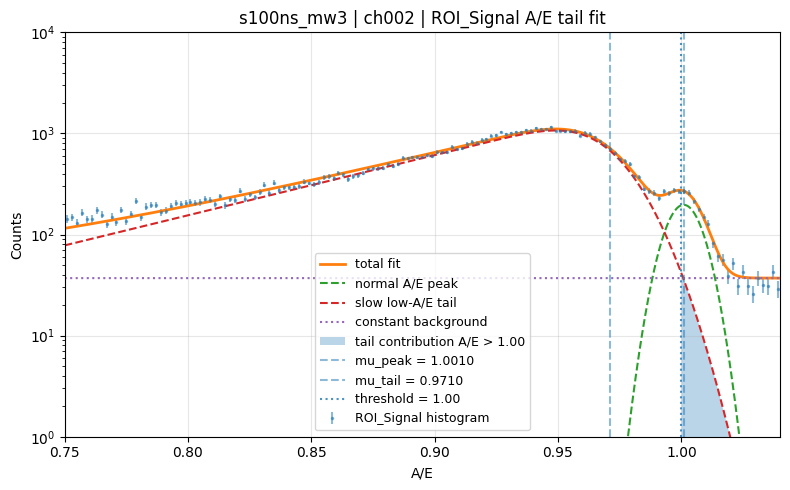

mu_peak = 1.000956298615746 +/- 0.0003674820485772425
mu_tail = 0.9710150846799338 +/- 0.00025522539729715837
tau = 0.07285821295602281 +/- 0.0007862734467568248
n_slow_tail_total = 54953.876691040015 +/- 234.4224321412949
fom_slow_tail_fraction = 0.8334966473894583 +/- 0.0014508288437284703
fom_slow_tail_fraction_bg_sub = 0.969771140101609 +/- 0.0007192518241727917

=== s100ns_mw5 | ch002 ===


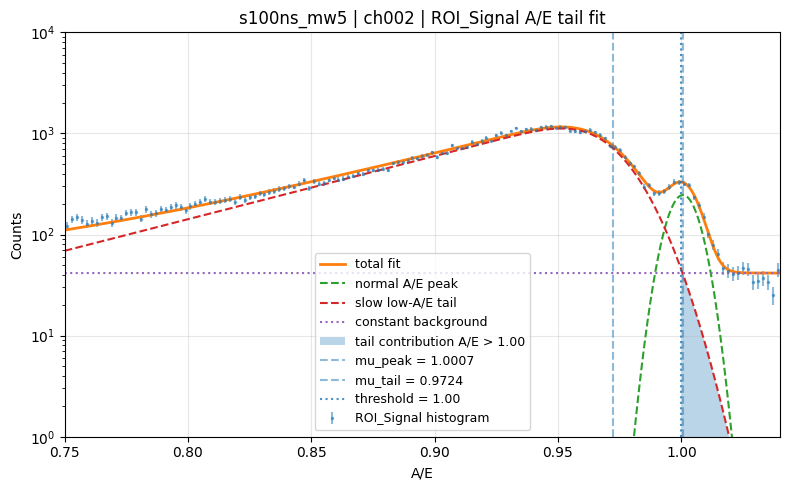

mu_peak = 1.00065385178026 +/- 0.0002739439887119817
mu_tail = 0.9724264556921389 +/- 0.00024283898918725006
tau = 0.06944036305040027 +/- 0.0007268545882535932
n_slow_tail_total = 55314.118368984215 +/- 235.1895371163101
fom_slow_tail_fraction = 0.8188451972428639 +/- 0.001481865322072074
fom_slow_tail_fraction_bg_sub = 0.9677583594647232 +/- 0.0007388520793741089

=== s100ns_mw7 | ch002 ===


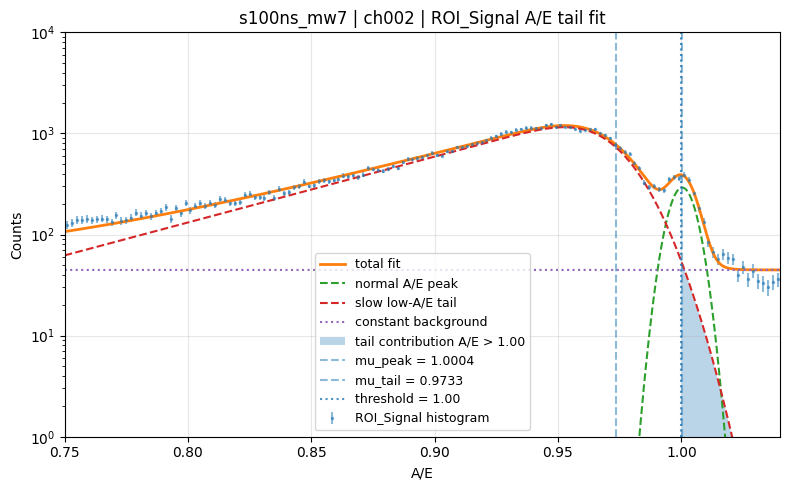

mu_peak = 1.0003664379161814 +/- 0.0002173709311158389
mu_tail = 0.9733416976953377 +/- 0.00023908067622998162
tau = 0.0666032739520873 +/- 0.0006843550250063419
n_slow_tail_total = 55727.88642752195 +/- 236.06754632418654
fom_slow_tail_fraction = 0.8103026299629177 +/- 0.0014950014621154728
fom_slow_tail_fraction_bg_sub = 0.9672855301373007 +/- 0.0007411196846274726

=== s200ns_mw3 | ch002 ===


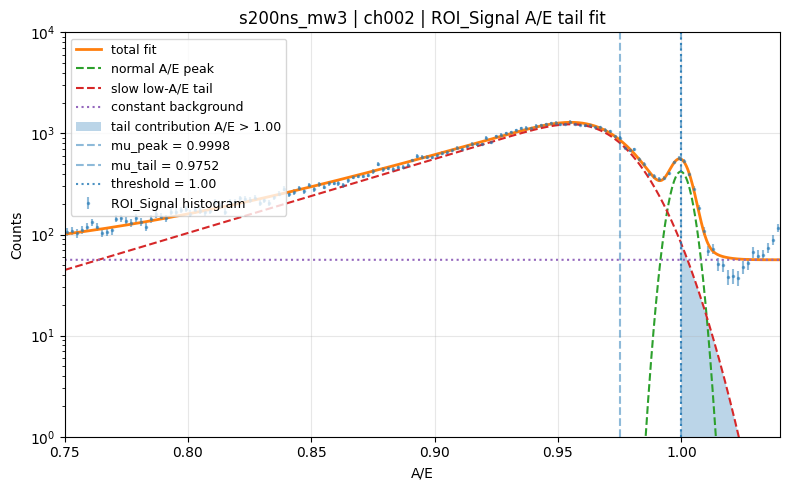

mu_peak = 0.9997585998789119 +/- 0.00014752197759555598
mu_tail = 0.9751880429939385 +/- 0.0002351349514073149
tau = 0.05926541748616626 +/- 0.0006144256878526223
n_slow_tail_total = 55924.34317296117 +/- 236.48328307295037
fom_slow_tail_fraction = 0.7752965178383762 +/- 0.0015540761255742903
fom_slow_tail_fraction_bg_sub = 0.9629719222989371 +/- 0.0007835717347817078

=== s200ns_mw5 | ch002 ===


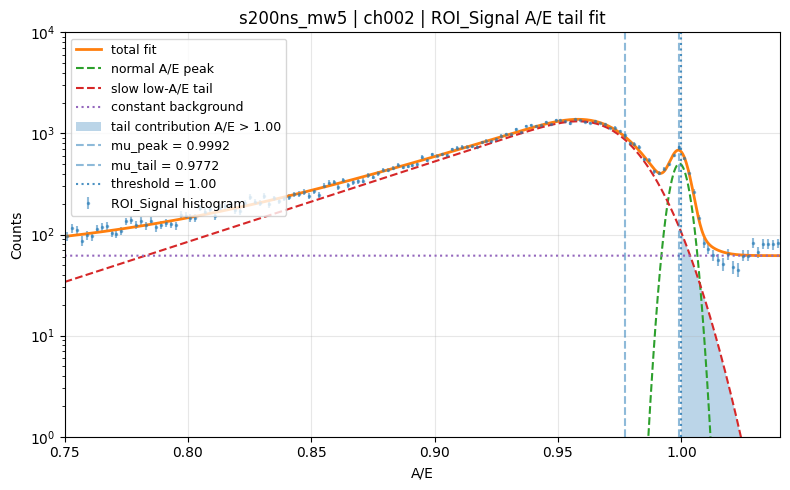

mu_peak = 0.9992256977440198 +/- 0.0001242608878087639
mu_tail = 0.9772119293601402 +/- 0.00022682437169611706
tau = 0.05461062996209188 +/- 0.0005605295685602444
n_slow_tail_total = 56490.919724558684 +/- 237.67818520966262
fom_slow_tail_fraction = 0.7614636959299351 +/- 0.0015647217616969011
fom_slow_tail_fraction_bg_sub = 0.9617200631967552 +/- 0.0007916714068318768

=== s200ns_mw7 | ch002 ===


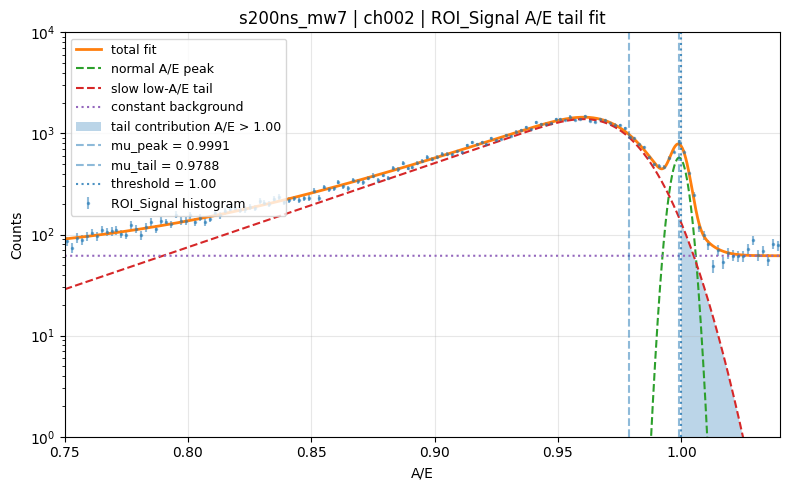

mu_peak = 0.9991181318625965 +/- 0.00010789209193875141
mu_tail = 0.9788458791019335 +/- 0.0002200553946693059
tau = 0.05215461786630285 +/- 0.0005224849986185836
n_slow_tail_total = 57407.564309567446 +/- 239.5987569032182
fom_slow_tail_fraction = 0.7641434347774851 +/- 0.0015488676549913045
fom_slow_tail_fraction_bg_sub = 0.9614052933968578 +/- 0.0007882896425953573


In [35]:
tail_fit_df, tail_fit_db = run_tail_fits_over_runs(
    runs=runs,
    all_db=all_db,
    channel="ch002",
    bins=250,
    value_range=(0.75, 1.25),
    hist_key="ROI_Signal",
    counts_key="counts",
    fit_range=(0.75, 1.04),
    threshold=1.0,
    plot=True,
    ylim=(1, 1e4),
)

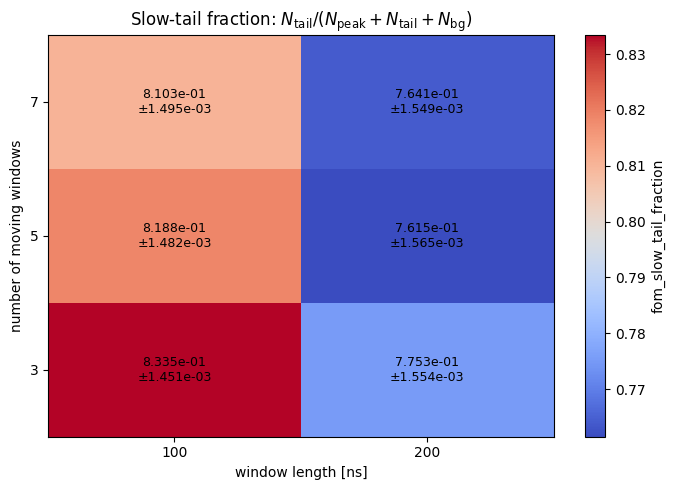

In [43]:
fig, ax, pivot_raw, matrix, _ = plot_window_mw_heatmap(
    tail_fit_df,
    value_col="fom_slow_tail_fraction",
    err_col="fom_slow_tail_fraction_err",
    title=r"Slow-tail fraction: $N_{\mathrm{tail}}/(N_{\mathrm{peak}}+N_{\mathrm{tail}}+N_{\mathrm{bg}})$",
    cmap="coolwarm",
    annotate=True,
    fmt=".3e",
)

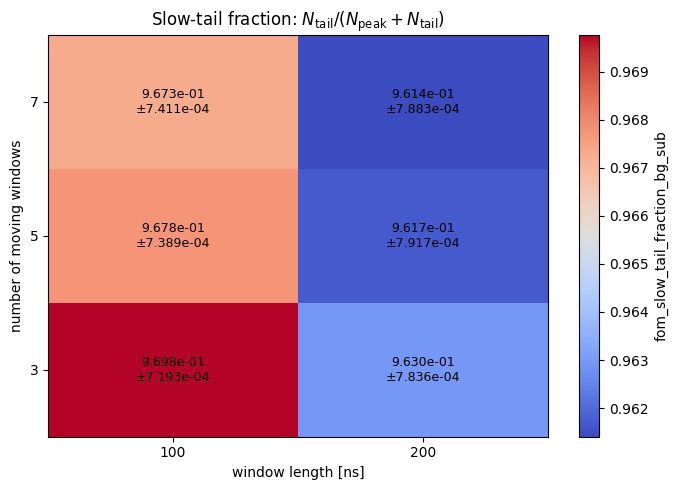

In [42]:
fig, ax, pivot_raw, matrix, _ = plot_window_mw_heatmap(
    tail_fit_df,
    value_col="fom_slow_tail_fraction_bg_sub",
    err_col="fom_slow_tail_fraction_bg_sub_err",
    title=r"Slow-tail fraction: $N_{\mathrm{tail}}/(N_{\mathrm{peak}}+N_{\mathrm{tail}})$",
    cmap="coolwarm",
    annotate=True,
    fmt=".3e",
)